
# Hausa Sentiment Analysis: Code-Mix vs Monolingual (Size-Matched Redesign)

This notebook redoes the code-mix vs. monolingual vs. combined sentiment
experiment with the following fixes over the original draft:

1. **Dataset**: uses AfriSenti's Hausa subset (Muhammad et al., 2023) instead of
   merging a small, differently-collected dataset (Abubakar et al., 2021) with
   NaijaSenti. One consistent collection pipeline, ~22k tweets for Hausa.
2. **Size-matched training conditions**: monolingual-only, code-mixed-only, and
   combined training sets are built to be the **same size**, so any performance
   difference is attributable to data *type*, not data *amount*. The old,
   unmatched ("natural") sizes are also kept so you can see the difference
   this control makes.
3. **Variance reporting**: every model/condition is trained with multiple
   random seeds; results are reported as mean ± standard deviation.
4. **Baselines**: a majority-class baseline and a TF-IDF + Logistic Regression
   baseline are included, with the exact feature representation stated.
5. **Class distribution**: reported and plotted for every split and condition.
6. **Train/dev/test sizes per condition**: reported explicitly in a table.

> **Runtime note**: Set `RUNTIME_MODE = "quick"` first to sanity-check the
> whole pipeline on a tiny sample before committing to the full run
> (`RUNTIME_MODE = "full"`), which needs a GPU runtime (Runtime > Change
> runtime type > GPU) and will take a while for several models × conditions × seeds.


## 1. Setup

In [ ]:

# Run this once per Colab session.
!pip install -q datasets transformers accelerate evaluate scikit-learn nltk sentencepiece


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.9 MB/s eta 0:00:00


In [ ]:

import os
import random
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from datasets import load_dataset, Dataset, DatasetDict
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding, set_seed
)

import nltk
nltk.download("words", quiet=True)
nltk.download("stopwords", quiet=True)
from nltk.corpus import words as nltk_words, stopwords as nltk_stopwords

# --------------------------- CONFIG ----------------------------------------
RUNTIME_MODE = "quick"          # "quick" (sanity check) or "full" (real run)
QUICK_SAMPLE_SIZE = 200         # tweets per condition when RUNTIME_MODE == "quick"
SEEDS = [13, 42, 2024]          # multiple seeds -> mean +/- std
N_EPOCHS = 3
BATCH_SIZE = 16
MAX_LEN = 128

# Models to compare. Trim this list if you're short on Colab GPU time.
MODEL_CHECKPOINTS = {
    "mBERT":            "bert-base-multilingual-cased",
    "XLM-R-base":       "xlm-roberta-base",
    "AfroXLMR-base":    "Davlan/afro-xlmr-base",
    "XLMR-base-Hausa":  "Davlan/xlm-roberta-base-finetuned-hausa",
}

LABEL2ID = {"negative": 0, "neutral": 1, "positive": 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

OUTPUT_DIR = "/content/hausa_sentiment_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


Device: cuda


## 2. Load AfriSenti Hausa data

Uses the official Hugging Face release of AfriSenti, Hausa config (`"hau"`),
which already provides `train` / `validation` / `test` splits with `tweet`
and `label` fields (Muhammad et al., 2023).

In [ ]:

# NOTE: HausaNLP/AfriSenti-Twitter uses a legacy loading script that is no
# longer supported by current versions of the datasets library
# (RuntimeError: "Dataset scripts are no longer supported"). masakhane/afrisenti
# hosts the same AfriSenti data auto-converted to Parquet, so we use that
# repo instead. Same Hausa split sizes: 14,173 / 2,678 / 5,304 (train/dev/test).
raw = load_dataset("masakhane/afrisenti", "hau")
print(raw)

official_sizes = {split: len(raw[split]) for split in raw}
print("\nOfficial AfriSenti Hausa split sizes:")
for k, v in official_sizes.items():
    print(f"  {k}: {v}")


README.md:   0%|          | 0.00/10.9k [00:00<?, ?B/s]

train.tsv:   0%|          | 0.00/1.34M [00:00<?, ?B/s]

dev.tsv:   0%|          | 0.00/265k [00:00<?, ?B/s]

test.tsv:   0%|          | 0.00/408k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/14172 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2677 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5303 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['tweet', 'label'],
        num_rows: 14172
    })
    validation: Dataset({
        features: ['tweet', 'label'],
        num_rows: 2677
    })
    test: Dataset({
        features: ['tweet', 'label'],
        num_rows: 5303
    })
})

Official AfriSenti Hausa split sizes:
  train: 14172
  validation: 2677
  test: 5303


## 3. Class distribution in the official splits

Reported before any resampling, so you can see the natural label balance.

In [ ]:

def class_distribution(dataset, name):
    labels = dataset["label"]
    counts = pd.Series(labels).value_counts()
    pct = (counts / counts.sum() * 100).round(1)
    df = pd.DataFrame({"count": counts, "percent": pct}).sort_index()
    df.index.name = f"{name} label"
    return df

official_dist = {split: class_distribution(raw[split], split) for split in raw}
for split, df in official_dist.items():
    print(f"\n--- {split} ---")
    print(df)



--- train ---
             count  percent
train label                
negative      4573     32.3
neutral       4912     34.7
positive      4687     33.1

--- validation ---
                  count  percent
validation label                
negative            894     33.4
neutral             896     33.5
positive            887     33.1

--- test ---
            count  percent
test label                
negative     1759     33.2
neutral      1789     33.7
positive     1755     33.1


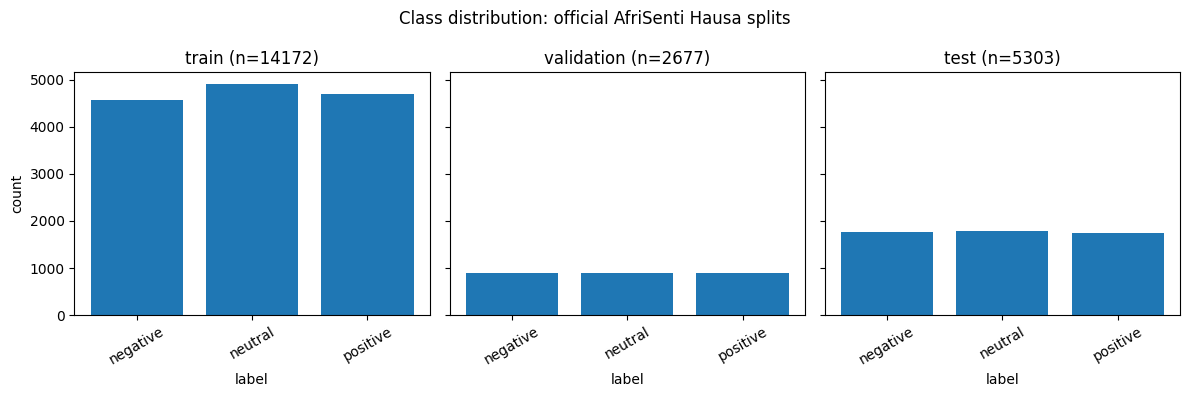

In [ ]:

fig, axes = plt.subplots(1, len(official_dist), figsize=(4 * len(official_dist), 4), sharey=True)
for ax, (split, df) in zip(axes, official_dist.items()):
    ax.bar(df.index.astype(str), df["count"])
    ax.set_title(f"{split} (n={df['count'].sum()})")
    ax.set_xlabel("label")
    ax.tick_params(axis='x', rotation=30)
axes[0].set_ylabel("count")
fig.suptitle("Class distribution: official AfriSenti Hausa splits")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/class_distribution_official.png", dpi=150)
plt.show()


## 4. Identify code-mixed vs. monolingual tweets

AfriSenti's public release does not ship a per-tweet monolingual/code-mix
flag (unlike the original NaijaSenti paper's internal annotation). To split
the pool into the two types, we use a **transparent, rule-based heuristic**:
a tweet is flagged as **code-mixed** if it contains a high enough proportion
of common English words; otherwise it is treated as **monolingual Hausa**.

> **Limitation to state explicitly in the paper**: this is a heuristic label,
> not a human annotation. It should be reported as such, and ideally a small
> random sample (e.g., 100 tweets) should be manually checked to report the
> heuristic's precision/recall before trusting the split fully.


In [ ]:

ENGLISH_WORDS = set(w.lower() for w in nltk_words.words())
ENGLISH_STOPWORDS = set(nltk_stopwords.words("english"))
ENGLISH_VOCAB = ENGLISH_WORDS | ENGLISH_STOPWORDS

TOKEN_RE = re.compile(r"[A-Za-z']+")

def english_token_ratio(text):
    tokens = TOKEN_RE.findall(text.lower())
    tokens = [t for t in tokens if len(t) > 2]  # skip very short tokens (noisy)
    if not tokens:
        return 0.0
    n_english = sum(1 for t in tokens if t in ENGLISH_VOCAB)
    return n_english / len(tokens)

CODE_MIX_THRESHOLD = 0.25  # >=25% recognizably English tokens -> code-mixed

def tag_mix_type(example):
    ratio = english_token_ratio(example["tweet"])
    example["english_ratio"] = ratio
    example["mix_type"] = "code-mix" if ratio >= CODE_MIX_THRESHOLD else "monolingual"
    return example

tagged = {split: raw[split].map(tag_mix_type) for split in raw}

for split, ds in tagged.items():
    counts = pd.Series(ds["mix_type"]).value_counts()
    print(f"{split}: {dict(counts)}")


Map:   0%|          | 0/14172 [00:00<?, ? examples/s]

Map:   0%|          | 0/2677 [00:00<?, ? examples/s]

Map:   0%|          | 0/5303 [00:00<?, ? examples/s]

train: {'code-mix': np.int64(10716), 'monolingual': np.int64(3456)}
validation: {'code-mix': np.int64(2013), 'monolingual': np.int64(664)}
test: {'code-mix': np.int64(2664), 'monolingual': np.int64(2639)}


In [ ]:

# Sanity check: look at a handful of examples from each category
for split_name in ["train"]:
    df = tagged[split_name].to_pandas()
    print("=== Sample tagged as CODE-MIX ===")
    print(df[df.mix_type == "code-mix"][["tweet", "english_ratio"]].head(5).to_string(index=False))
    print("\n=== Sample tagged as MONOLINGUAL ===")
    print(df[df.mix_type == "monolingual"][["tweet", "english_ratio"]].head(5).to_string(index=False))


=== Sample tagged as CODE-MIX ===
                                                                                                                                                                                                                                                                               tweet  english_ratio
                                                                                                                                                @user Kaga wani Adu ar Banda💔😭 wai a haka Shi ne shugaban sojoji.... Gaskiya Buhari kaci Amanan mu da kasa wannan mutum ah wajen nan       0.263158
                                                                                                                                                                                                               @user Sai haquri fa yan madrid daman kunce champion din ya muku yawa😂       0.636364
@user Hmmm yanzu kai kasan girman allah daxakace mukuma ga Allah kune kukabarshi kuna kary

## 5. Build size-matched training conditions

Three training conditions are built **at the same total size** `N`:

- **Monolingual-only**: N tweets sampled from the monolingual pool
- **Code-mixed-only**: N tweets sampled from the code-mixed pool
- **Combined**: N/2 monolingual + N/2 code-mixed tweets

`N` is set to twice the size of the smaller pool (so combined can draw its
full N/2+N/2 without upsampling with replacement), unless that would exceed
what's available — the code checks this automatically. Sampling is done
**without replacement** and with a fixed seed for reproducibility.

The "natural" (unmatched) version — using each pool at its full available
size — is also built, purely so you can show, side by side, how much of the
old result was driven by data volume rather than data type.


In [ ]:

def build_conditions(train_ds, seed=42):
    df = train_ds.to_pandas()
    mono_pool = df[df.mix_type == "monolingual"].sample(frac=1, random_state=seed).reset_index(drop=True)
    mix_pool  = df[df.mix_type == "code-mix"].sample(frac=1, random_state=seed).reset_index(drop=True)

    # ---- size-matched N ----
    smaller_pool = min(len(mono_pool), len(mix_pool))
    N = smaller_pool  # each single-type condition gets N examples
    half = N // 2      # combined draws half from each pool

    conditions_matched = {
        "monolingual_matched": mono_pool.iloc[:N],
        "codemix_matched":     mix_pool.iloc[:N],
        "combined_matched":    pd.concat([mono_pool.iloc[:half], mix_pool.iloc[:half]], ignore_index=True)
                                  .sample(frac=1, random_state=seed).reset_index(drop=True),
    }

    # ---- natural (unmatched) sizes, for comparison only ----
    conditions_natural = {
        "monolingual_natural": mono_pool,
        "codemix_natural":     mix_pool,
        "combined_natural":    pd.concat([mono_pool, mix_pool], ignore_index=True)
                                  .sample(frac=1, random_state=seed).reset_index(drop=True),
    }

    return conditions_matched, conditions_natural

conditions_matched, conditions_natural = build_conditions(tagged["train"], seed=42)

print("Size-matched conditions (train):")
for name, d in conditions_matched.items():
    print(f"  {name}: {len(d)}")

print("\nNatural (unmatched) conditions (train):")
for name, d in conditions_natural.items():
    print(f"  {name}: {len(d)}")


Size-matched conditions (train):
  monolingual_matched: 3456
  codemix_matched: 3456
  combined_matched: 3456

Natural (unmatched) conditions (train):
  monolingual_natural: 3456
  codemix_natural: 10716
  combined_natural: 14172


## 6. Report train / dev / test sizes per condition (explicit table)

In [ ]:

# Dev and test stay as the official, held-out AfriSenti splits for every
# condition — only the TRAIN set changes between conditions. This keeps
# evaluation fair and comparable across all training conditions.
dev_ds = tagged["validation"]
test_ds = tagged["test"]

rows = []
for name, d in {**conditions_matched, **conditions_natural}.items():
    rows.append({
        "condition": name,
        "train_size": len(d),
        "dev_size": len(dev_ds),
        "test_size": len(test_ds),
    })
size_table = pd.DataFrame(rows)
print(size_table.to_string(index=False))
size_table.to_csv(f"{OUTPUT_DIR}/train_dev_test_sizes.csv", index=False)


          condition  train_size  dev_size  test_size
monolingual_matched        3456      2677       5303
    codemix_matched        3456      2677       5303
   combined_matched        3456      2677       5303
monolingual_natural        3456      2677       5303
    codemix_natural       10716      2677       5303
   combined_natural       14172      2677       5303


## 7. Class distribution per training condition

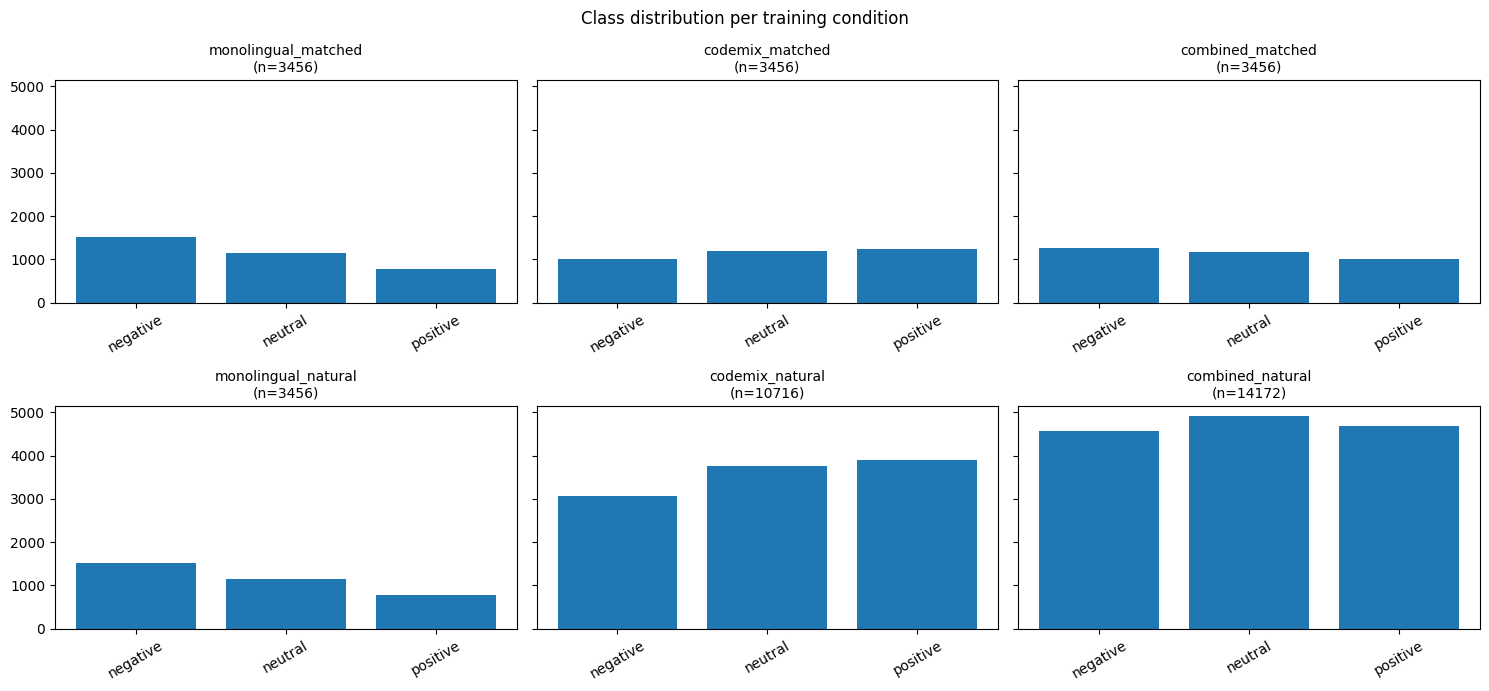

In [ ]:

fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharey=True)
all_conditions = {**conditions_matched, **conditions_natural}
for ax, (name, d) in zip(axes.flat, all_conditions.items()):
    counts = d["label"].value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values)
    ax.set_title(f"{name}\n(n={len(d)})", fontsize=10)
    ax.tick_params(axis='x', rotation=30)
fig.suptitle("Class distribution per training condition")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/class_distribution_by_condition.png", dpi=150)
plt.show()


## 8. Baselines

Two baselines, reported once (they are not stochastic in a way that needs
multi-seed averaging beyond the classifier's own random_state, which is
still seeded across the same SEEDS list for consistency):

- **Majority-class baseline**: predicts the most frequent training label for
  every example. This is the absolute floor any real model must beat.
- **TF-IDF + Logistic Regression**: features are **TF-IDF weighted unigrams
  and bigrams, `max_features=20000`, `min_df=2`**, stated explicitly here so
  the experiment is reproducible (this was missing in the earlier draft).


In [ ]:

def run_baselines(train_df, dev_ds, test_ds, seed):
    set_seed(seed)
    X_train_text, y_train = train_df["tweet"].tolist(), train_df["label"].tolist()
    X_test_text, y_test = test_ds["tweet"], test_ds["label"]

    results = {}

    # Majority-class baseline
    dummy = DummyClassifier(strategy="most_frequent", random_state=seed)
    dummy.fit(np.zeros((len(y_train), 1)), y_train)
    pred_dummy = dummy.predict(np.zeros((len(y_test), 1)))
    results["majority_class"] = {
        "f1_weighted": f1_score(y_test, pred_dummy, average="weighted", zero_division=0),
        "accuracy": accuracy_score(y_test, pred_dummy),
    }

    # TF-IDF + Logistic Regression
    vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=20000, min_df=2)
    X_train = vectorizer.fit_transform(X_train_text)
    X_test = vectorizer.transform(X_test_text)
    clf = LogisticRegression(max_iter=1000, random_state=seed)
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)
    results["tfidf_logreg"] = {
        "f1_weighted": f1_score(y_test, pred, average="weighted", zero_division=0),
        "accuracy": accuracy_score(y_test, pred),
    }
    return results

baseline_rows = []
for cond_name, cond_df in {**conditions_matched, **conditions_natural}.items():
    for seed in SEEDS:
        res = run_baselines(cond_df, dev_ds, test_ds, seed)
        for model_name, metrics in res.items():
            baseline_rows.append({"condition": cond_name, "model": model_name, "seed": seed, **metrics})

baseline_df = pd.DataFrame(baseline_rows)
baseline_summary = baseline_df.groupby(["condition", "model"]).agg(
    f1_mean=("f1_weighted", "mean"), f1_std=("f1_weighted", "std"),
    acc_mean=("accuracy", "mean"), acc_std=("accuracy", "std"),
).reset_index()
print(baseline_summary.to_string(index=False))
baseline_summary.to_csv(f"{OUTPUT_DIR}/baseline_results.csv", index=False)


          condition          model  f1_mean  f1_std  acc_mean  acc_std
    codemix_matched majority_class 0.164581     0.0  0.330945      0.0
    codemix_matched   tfidf_logreg 0.677125     0.0  0.676410      0.0
    codemix_natural majority_class 0.164581     0.0  0.330945      0.0
    codemix_natural   tfidf_logreg 0.728156     0.0  0.727701      0.0
   combined_matched majority_class 0.165239     0.0  0.331699      0.0
   combined_matched   tfidf_logreg 0.652984     0.0  0.655667      0.0
   combined_natural majority_class 0.170200     0.0  0.337356      0.0
   combined_natural   tfidf_logreg 0.730757     0.0  0.731284      0.0
monolingual_matched majority_class 0.165239     0.0  0.331699      0.0
monolingual_matched   tfidf_logreg 0.619119     0.0  0.628135      0.0
monolingual_natural majority_class 0.165239     0.0  0.331699      0.0
monolingual_natural   tfidf_logreg 0.619119     0.0  0.628135      0.0


## 9. Fine-tuning transformer models

Each checkpoint in `MODEL_CHECKPOINTS` is fine-tuned on each training
condition, for each seed in `SEEDS`, then evaluated on the three official
test-type views: the full official test set, and (for reporting comparable
to the original paper) the code-mix-only and monolingual-only subsets of
that same official test set — using the same heuristic tag from Step 4.


In [ ]:

test_df_tagged = tagged["test"].to_pandas()
eval_sets = {
    "combine":     tagged["test"],
    "codemix":     Dataset.from_pandas(test_df_tagged[test_df_tagged.mix_type == "code-mix"].reset_index(drop=True)),
    "monolingual": Dataset.from_pandas(test_df_tagged[test_df_tagged.mix_type == "monolingual"].reset_index(drop=True)),
}
for name, ds in eval_sets.items():
    print(f"{name}: {len(ds)} test examples")


combine: 5303 test examples
codemix: 2664 test examples
monolingual: 2639 test examples


In [ ]:

def tokenize_dataset(tokenizer, df_or_ds):
    if isinstance(df_or_ds, pd.DataFrame):
        ds = Dataset.from_pandas(df_or_ds[["tweet", "label"]].reset_index(drop=True))
    else:
        ds = df_or_ds
    ds = ds.map(lambda x: {"labels": LABEL2ID[x["label"]]})
    ds = ds.map(lambda x: tokenizer(x["tweet"], truncation=True, max_length=MAX_LEN), batched=True)

    # Drop every column the model/collator shouldn't see. Keeping the
    # original string "label" (or "tweet", "mix_type", "english_ratio",
    # "__index_level_0__") alongside the new int "labels" column causes the
    # Trainer to try to tensor-ify the string column too, which raises
    # "ValueError: too many dimensions 'str'" during training.
    keep = {"input_ids", "attention_mask", "token_type_ids", "labels"}
    drop_cols = [c for c in ds.column_names if c not in keep]
    ds = ds.remove_columns(drop_cols)
    return ds

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "f1_weighted": f1_score(labels, preds, average="weighted", zero_division=0),
        "accuracy": accuracy_score(labels, preds),
    }

def train_and_evaluate(checkpoint, condition_name, train_df, seed):
    set_seed(seed)
    tokenizer = AutoTokenizer.from_pretrained(checkpoint)
    model = AutoModelForSequenceClassification.from_pretrained(
        checkpoint, num_labels=3, id2label=ID2LABEL, label2id=LABEL2ID
    )

    train_tok = tokenize_dataset(tokenizer, train_df)
    dev_tok = tokenize_dataset(tokenizer, dev_ds)
    collator = DataCollatorWithPadding(tokenizer=tokenizer)

    args = TrainingArguments(
        output_dir=f"{OUTPUT_DIR}/tmp_{checkpoint.replace('/', '_')}_{condition_name}_{seed}",
        num_train_epochs=N_EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        eval_strategy="epoch",
        save_strategy="no",
        logging_steps=50,
        seed=seed,
        report_to=[],
        fp16=torch.cuda.is_available(),
    )

    trainer = Trainer(
        model=model, args=args,
        train_dataset=train_tok, eval_dataset=dev_tok,
        data_collator=collator, compute_metrics=compute_metrics,
    )
    trainer.train()

    row_results = {}
    for eval_name, eval_ds in eval_sets.items():
        eval_tok = tokenize_dataset(tokenizer, eval_ds)
        metrics = trainer.evaluate(eval_tok)
        row_results[eval_name] = {
            "f1_weighted": metrics["eval_f1_weighted"],
            "accuracy": metrics["eval_accuracy"],
        }
    del model, trainer
    torch.cuda.empty_cache()
    return row_results


In [ ]:

# --------------------------------------------------------------------------
# Main experiment loop. In "quick" mode this subsamples every condition down
# to QUICK_SAMPLE_SIZE rows and uses 1 epoch, purely to check the pipeline
# runs end-to-end before committing GPU time to the full run.
# --------------------------------------------------------------------------
all_conditions_for_training = {**conditions_matched, **conditions_natural}

if RUNTIME_MODE == "quick":
    all_conditions_for_training = {
        name: df.sample(n=min(QUICK_SAMPLE_SIZE, len(df)), random_state=0)
        for name, df in all_conditions_for_training.items()
    }
    N_EPOCHS = 1
    SEEDS_TO_USE = SEEDS[:1]
    MODELS_TO_USE = dict(list(MODEL_CHECKPOINTS.items())[:1])
    print("RUNNING IN QUICK MODE — results are NOT meaningful, this only checks the code runs.")
else:
    SEEDS_TO_USE = SEEDS
    MODELS_TO_USE = MODEL_CHECKPOINTS

results_rows = []
for model_name, checkpoint in MODELS_TO_USE.items():
    for condition_name, train_df in all_conditions_for_training.items():
        for seed in SEEDS_TO_USE:
            print(f"\n=== {model_name} | train={condition_name} | seed={seed} ===")
            res = train_and_evaluate(checkpoint, condition_name, train_df, seed)
            for eval_name, metrics in res.items():
                results_rows.append({
                    "model": model_name,
                    "train_condition": condition_name,
                    "eval_condition": eval_name,
                    "seed": seed,
                    **metrics,
                })

results_df = pd.DataFrame(results_rows)
results_df.to_csv(f"{OUTPUT_DIR}/raw_results_per_seed.csv", index=False)
results_df.head()


RUNNING IN QUICK MODE — results are NOT meaningful, this only checks the code runs.

=== mBERT | train=monolingual_matched | seed=13 ===


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

...

Training Loss,Validation Loss,Epoch,F1 Weighted,Accuracy
No log,1.061874,1,0.350869,0.441441


Map:   0%|          | 0/2639 [00:00<?, ? examples/s]

Map:   0%|          | 0/2639 [00:00<?, ? examples/s]

Training Loss,Validation Loss,Epoch,F1 Weighted,Accuracy
No log,1.098709,1,0.271388,0.343312


,model,train_condition,eval_condition,seed,f1_weighted,accuracy
0,mBERT,monolingual_matched,combine,13,0.165239,0.331699
1,mBERT,monolingual_matched,codemix,13,0.124872,0.283033
2,mBERT,monolingual_matched,monolingual,13,0.210060,0.380826
3,mBERT,codemix_matched,combine,13,0.186138,0.343768
4,mBERT,codemix_matched,codemix,13,0.181452,0.331456


## 10. Aggregate results: mean ± std across seeds

In [ ]:

summary = results_df.groupby(["model", "train_condition", "eval_condition"]).agg(
    f1_mean=("f1_weighted", "mean"), f1_std=("f1_weighted", "std"),
    acc_mean=("accuracy", "mean"), acc_std=("accuracy", "std"),
).reset_index()
summary["f1_std"] = summary["f1_std"].fillna(0.0)
summary["acc_std"] = summary["acc_std"].fillna(0.0)

summary_display = summary.copy()
summary_display["F1 (mean ± std)"] = summary_display.apply(
    lambda r: f"{r.f1_mean*100:.1f} ± {r.f1_std*100:.1f}", axis=1
)
print(summary_display[["model", "train_condition", "eval_condition", "F1 (mean ± std)"]].to_string(index=False))
summary.to_csv(f"{OUTPUT_DIR}/summary_results.csv", index=False)


model     train_condition eval_condition F1 (mean ± std)
mBERT     codemix_matched        codemix      18.1 ± 0.0
mBERT     codemix_matched        combine      18.6 ± 0.0
mBERT     codemix_matched    monolingual      19.1 ± 0.0
mBERT     codemix_natural        codemix      22.6 ± 0.0
mBERT     codemix_natural        combine      16.5 ± 0.0
mBERT     codemix_natural    monolingual      11.0 ± 0.0
mBERT    combined_matched        codemix      12.5 ± 0.0
mBERT    combined_matched        combine      16.5 ± 0.0
mBERT    combined_matched    monolingual      21.0 ± 0.0
mBERT    combined_natural        codemix      35.1 ± 0.0
mBERT    combined_natural        combine      30.8 ± 0.0
mBERT    combined_natural    monolingual      27.1 ± 0.0
mBERT monolingual_matched        codemix      12.5 ± 0.0
mBERT monolingual_matched        combine      16.5 ± 0.0
mBERT monolingual_matched    monolingual      21.0 ± 0.0
mBERT monolingual_natural        codemix      12.5 ± 0.0
mBERT monolingual_natural      

## 11. Key comparison: matched-size vs. natural-size

This is the plot that directly answers the confound question: does
"combined" still win once every training condition is the same size?


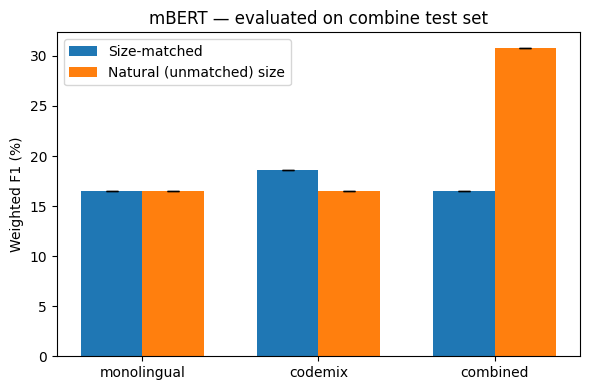

In [ ]:

def plot_matched_vs_natural(summary_df, model_name, eval_condition="combine"):
    sub = summary_df[(summary_df.model == model_name) & (summary_df.eval_condition == eval_condition)]
    matched = sub[sub.train_condition.str.endswith("_matched")].sort_values("train_condition")
    natural = sub[sub.train_condition.str.endswith("_natural")].sort_values("train_condition")

    labels = ["monolingual", "codemix", "combined"]
    matched_vals = [matched[matched.train_condition == f"{l}_matched"].f1_mean.values[0] * 100 if not matched[matched.train_condition == f"{l}_matched"].empty else np.nan for l in labels]
    matched_err  = [matched[matched.train_condition == f"{l}_matched"].f1_std.values[0] * 100 if not matched[matched.train_condition == f"{l}_matched"].empty else 0 for l in labels]
    natural_vals = [natural[natural.train_condition == f"{l}_natural"].f1_mean.values[0] * 100 if not natural[natural.train_condition == f"{l}_natural"].empty else np.nan for l in labels]
    natural_err  = [natural[natural.train_condition == f"{l}_natural"].f1_std.values[0] * 100 if not natural[natural.train_condition == f"{l}_natural"].empty else 0 for l in labels]

    x = np.arange(len(labels))
    width = 0.35
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(x - width/2, matched_vals, width, yerr=matched_err, capsize=4, label="Size-matched")
    ax.bar(x + width/2, natural_vals, width, yerr=natural_err, capsize=4, label="Natural (unmatched) size")
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel("Weighted F1 (%)")
    ax.set_title(f"{model_name} — evaluated on {eval_condition} test set")
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/matched_vs_natural_{model_name}_{eval_condition}.png", dpi=150)
    plt.show()

for model_name in MODELS_TO_USE:
    plot_matched_vs_natural(summary, model_name, eval_condition="combine")


## 12. Error analysis: confusion matrix for the best model/condition

In [ ]:

best_row = summary.loc[summary.f1_mean.idxmax()]
print("Best configuration overall:")
print(best_row)

# Re-run once (best seed by F1) to get predictions for a confusion matrix
best_seed_row = results_df[
    (results_df.model == best_row.model) &
    (results_df.train_condition == best_row.train_condition) &
    (results_df.eval_condition == best_row.eval_condition)
].sort_values("f1_weighted", ascending=False).iloc[0]
print("\nBest single run used for confusion matrix:", dict(best_seed_row))


Best configuration overall:
model                         mBERT
train_condition    combined_natural
eval_condition              codemix
f1_mean                    0.350869
f1_std                          0.0
acc_mean                   0.441441
acc_std                         0.0
Name: 9, dtype: object

Best single run used for confusion matrix: {'model': 'mBERT', 'train_condition': 'combined_natural', 'eval_condition': 'codemix', 'seed': np.int64(13), 'f1_weighted': np.float64(0.3508694841981513), 'accuracy': np.float64(0.44144144144144143)}


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Step,Training Loss


Map:   0%|          | 0/2664 [00:00<?, ? examples/s]

Map:   0%|          | 0/2664 [00:00<?, ? examples/s]

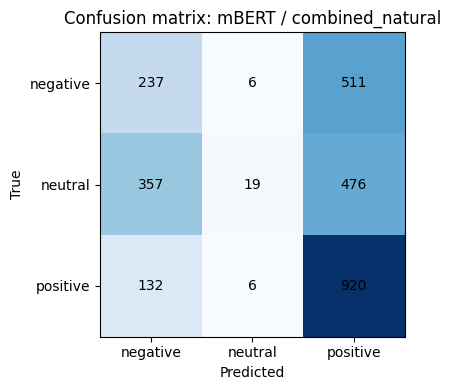

In [ ]:

# NOTE: This retrains once more to obtain predictions for the confusion matrix
# (Trainer.evaluate() above did not persist raw predictions). If you'd rather
# not retrain, modify train_and_evaluate() above to also return predictions.
checkpoint = MODEL_CHECKPOINTS[best_row.model]
train_df_best = all_conditions_for_training[best_row.train_condition]
seed_best = int(best_seed_row.seed)

set_seed(seed_best)
tokenizer = AutoTokenizer.from_pretrained(checkpoint)
model = AutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels=3, id2label=ID2LABEL, label2id=LABEL2ID)
train_tok = tokenize_dataset(tokenizer, train_df_best)
dev_tok = tokenize_dataset(tokenizer, dev_ds)
collator = DataCollatorWithPadding(tokenizer=tokenizer)
args = TrainingArguments(
    output_dir=f"{OUTPUT_DIR}/tmp_best", num_train_epochs=N_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE, per_device_eval_batch_size=BATCH_SIZE,
    eval_strategy="no", save_strategy="no", seed=seed_best, report_to=[], fp16=torch.cuda.is_available(),
)
trainer = Trainer(model=model, args=args, train_dataset=train_tok, data_collator=collator)
trainer.train()

eval_ds_best = eval_sets[best_row.eval_condition]
eval_tok = tokenize_dataset(tokenizer, eval_ds_best)
preds = trainer.predict(eval_tok)
y_true = preds.label_ids
y_pred = np.argmax(preds.predictions, axis=-1)

cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(3)); ax.set_xticklabels(["negative", "neutral", "positive"])
ax.set_yticks(range(3)); ax.set_yticklabels(["negative", "neutral", "positive"])
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha="center", va="center")
ax.set_title(f"Confusion matrix: {best_row.model} / {best_row.train_condition}")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confusion_matrix_best.png", dpi=150)
plt.show()


## 13. Save everything

All CSVs and figures are written to `/content/hausa_sentiment_outputs/`.
In Colab, download them via the Files panel, or mount Google Drive and copy
them there so they persist after the runtime disconnects:

```python
from google.colab import drive
drive.mount('/content/drive')
!cp -r /content/hausa_sentiment_outputs /content/drive/MyDrive/
```


In [ ]:

print("Files written to", OUTPUT_DIR, ":")
for f in sorted(os.listdir(OUTPUT_DIR)):
    print(" -", f)


Files written to /content/hausa_sentiment_outputs :
 - baseline_results.csv
 - class_distribution_by_condition.png
 - class_distribution_official.png
 - confusion_matrix_best.png
 - matched_vs_natural_mBERT_combine.png
 - raw_results_per_seed.csv
 - summary_results.csv
 - tmp_bert-base-multilingual-cased_codemix_matched_13
 - tmp_bert-base-multilingual-cased_codemix_natural_13
 - tmp_bert-base-multilingual-cased_combined_matched_13
 - tmp_bert-base-multilingual-cased_combined_natural_13
 - tmp_bert-base-multilingual-cased_monolingual_matched_13
 - tmp_bert-base-multilingual-cased_monolingual_natural_13
 - tmp_best
 - train_dev_test_sizes.csv


## Next steps for the paper

- Switch `RUNTIME_MODE` to `"full"` and run on a GPU runtime once the quick
  pipeline check above passes.
- Manually check ~100 tweets from the heuristic `mix_type` tagging (Step 4)
  and report precision/recall of the heuristic against human judgment — this
  turns "we used a heuristic" into a validated, citable procedure.
- Trim `MODEL_CHECKPOINTS` if Colab's free-tier GPU time runs out; 2 models ×
  3 conditions × 3 seeds is usually a reasonable first full run.
- Use `summary_results.csv` and the matched-vs-natural plots directly as the
  new Table 3 / Figure 1 in the paper, and report the class-distribution
  tables from Steps 3 and 7 as a new dataset-description table.
